# Analysis

In [1]:
import os, sys

# Environment setup (equivalent to shell exports)
sys.path.insert(0, os.path.abspath(".."))
os.environ["SSL_CERT_DIR"] = "/etc/ssl/certs"
os.environ.setdefault("OPENCLIP_CACHEDIR", os.path.expandvars("$SCRATCH/openclip"))

'/network/scratch/m/marawan.gamal/openclip'

In [4]:
import torch

def _get_eigcov(d: torch.Tensor, *args, **kwargs):
    c = d.transpose(1, 2) @ d
    return c

pinv = torch.linalg.pinv

d = torch.randn(3, 32, 64)
# c = d.transpose(1, 2) @ d
c = _get_eigcov(d)
gam = 1 / torch.linalg.norm(d, ord="fro", dim=(-2, -1), keepdim=True)
(gam * d @ c).sum(dim=0) @ pinv((c * gam).sum(dim=0))

tensor([[-2.6291,  0.6043, -1.4570,  ..., -1.9519, -1.0970, -2.6682],
        [-3.1135,  1.4433, -3.3082,  ..., -0.4828, -0.9028, -0.1780],
        [ 1.6258, -0.6673,  0.8650,  ..., -0.2050,  1.7706, -2.2243],
        ...,
        [-2.7072, -2.4659,  3.6469,  ..., -1.6393,  0.5539,  4.3920],
        [ 1.1074,  1.8754, -2.4101,  ..., -2.2259,  0.1869, -0.4476],
        [ 3.3741, -1.1734,  4.3388,  ...,  2.5122, -2.9719, -1.4882]])

## Fig. 1a: EigCov Estimation Error (Vision)

In [25]:
import sys
import os
import math
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import LinearizedTaskVector, NonLinearTaskVector


MODELS = ["ViT-B-16", "ViT-L-14"]
# MODELS = ["ViT-B-16"]
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
FT_METHODS = ["standard"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = None
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")
def dist_cos_noabs(A: torch.Tensor, B: torch.Tensor, *args, **kwargs) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    cos_theta = torch.dot(a, b) / (a.norm() * b.norm())
    return (1 - cos_theta)

max_layers_per_combo = MAX_LAYERS + 1 if MAX_LAYERS is not None else None
TOTAL = len(MODELS) * len(FT_METHODS) * len(DATASETS) * (max_layers_per_combo or 0)
global_step = 0

rows = []
for model_name in MODELS:
    results_dir = os.path.join(RESULTS_ROOT, model_name)
    checkpoint_dir = os.path.join(CHECKPOINTS_ROOT, model_name)
    # checkpoint_dir = f"../checkpoints/{model_name}"

    for ft_method, dataset in product(FT_METHODS, DATASETS):
        # Load covariance
        covs = np.load(f"{results_dir}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{ft_method}/covariance_{dataset}.npz", allow_pickle=True)

        # Load task vector
        if ft_method == "linear":
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/linear_zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/linear_finetuned.pt"
            pretrained_nonlinear_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"

            nonlinear_encoder = torch.load(
                pretrained_nonlinear_checkpoint, map_location="cpu", weights_only=False
            )
            param_names = [n for n, _ in nonlinear_encoder.named_parameters()]
            del nonlinear_encoder

            tv = LinearizedTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )
            encoder = tv.apply_to_nonlinear(
                pretrained_nonlinear_checkpoint, param_names, scaling_coef=1.0
            )
            task_vector = NonLinearTaskVector(
                vector=encoder.state_dict(),
            )
        elif ft_method == "lora":
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/lora_finetuned.pt"
            task_vector = NonLinearTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )
        else:
            pretrained_checkpoint = f"{checkpoint_dir}/{dataset}Val/zeroshot.pt"
            finetuned_checkpoint = f"{checkpoint_dir}/{dataset}Val/finetuned.pt"
            task_vector = NonLinearTaskVector(
                pretrained_checkpoint,
                finetuned_checkpoint,
            )

        task_vector = task_vector.map(mhas.copy_from_pytorch_state_dict)

        num_added = 0
        if TOTAL == 0 and MAX_LAYERS is None:
            TOTAL = len(MODELS) * len(FT_METHODS) * len(DATASETS) * len(task_vector.vector)
        for k, m in task_vector.vector.items():
            kp = param_name_to_module_name(k)
            if len(m.shape) != 2 or kp not in covs.keys():
                continue
            m = m.to(DEVICE)
            c = torch.from_numpy(covs[kp]).to(m.dtype).to(DEVICE)
            c_hat_ident = torch.eye(c.shape[0], c.shape[1], dtype=c.dtype, device=DEVICE)
            c_hat_ec = m.T @ m
            c_hat_rand = torch.randn_like(c, device=DEVICE)
            for method, c_hat in [
                ("EigenCov", c_hat_ec),
                ("Random", c_hat_rand),
                ("Identity", c_hat_ident),
            ]:
                rows.append({
                    "model": model_name, "dataset": dataset, "layer_name": k,
                    "layer_idx": num_added, "method": method,
                    "error": dist_cos_noabs(c, c_hat).item(), "ft_method": ft_method,
                })
            global_step += 1
            print(f"[{global_step}/{TOTAL}] {model_name} | {ft_method} | {dataset} | layer {num_added} | {k.split('.')[-2]}")
            num_added += 1
            if MAX_LAYERS is not None and num_added > MAX_LAYERS:
                break

# Save
df = pd.DataFrame(rows)
df.to_csv(SAVE_PATH, index=False)

[1/2472] ViT-B-16 | standard | Cars | layer 0 | c_fc
[2/2472] ViT-B-16 | standard | Cars | layer 1 | c_proj
[3/2472] ViT-B-16 | standard | Cars | layer 2 | c_fc
[4/2472] ViT-B-16 | standard | Cars | layer 3 | c_proj
[5/2472] ViT-B-16 | standard | Cars | layer 4 | c_fc
[6/2472] ViT-B-16 | standard | Cars | layer 5 | c_proj
[7/2472] ViT-B-16 | standard | Cars | layer 6 | c_fc
[8/2472] ViT-B-16 | standard | Cars | layer 7 | c_proj
[9/2472] ViT-B-16 | standard | Cars | layer 8 | c_fc
[10/2472] ViT-B-16 | standard | Cars | layer 9 | c_proj
[11/2472] ViT-B-16 | standard | Cars | layer 10 | c_fc
[12/2472] ViT-B-16 | standard | Cars | layer 11 | c_proj
[13/2472] ViT-B-16 | standard | Cars | layer 12 | c_fc
[14/2472] ViT-B-16 | standard | Cars | layer 13 | c_proj
[15/2472] ViT-B-16 | standard | Cars | layer 14 | c_fc
[16/2472] ViT-B-16 | standard | Cars | layer 15 | c_proj
[17/2472] ViT-B-16 | standard | Cars | layer 16 | c_fc
[18/2472] ViT-B-16 | standard | Cars | layer 17 | c_proj
[19/2472] V

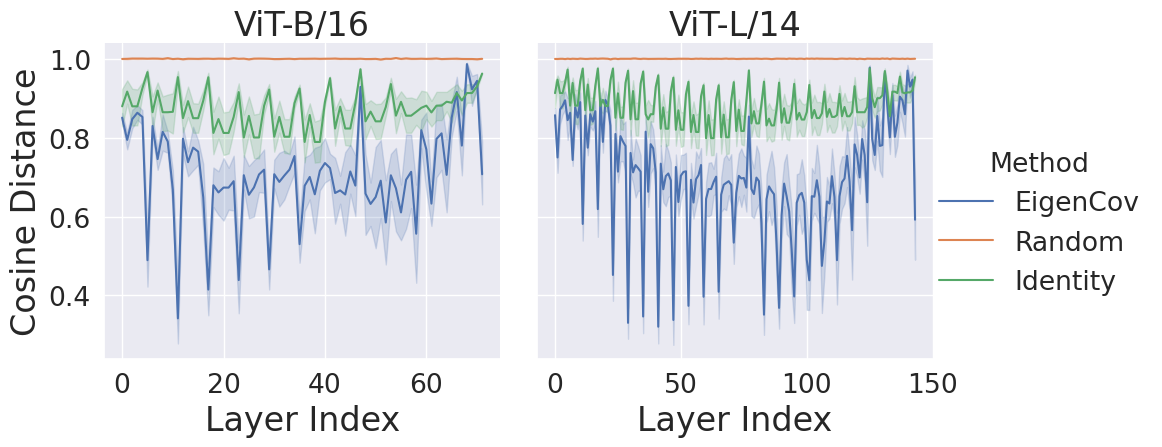

In [38]:
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"ViT-B-16": "ViT-B/16", "ViT-B-32": "ViT-B/32", "ViT-L-14": "ViT-L/14"}

df = pd.read_csv(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df = df[df["ft_method"] == "standard"]
df = df[df["method"] != "Zeros"]
df["model"] = df["model"].map(MODEL_MAP).fillna(df["model"])

# Re-index layers: natural sort by layer_name within each model
def natural_sort_key(s):
    return [int(tok) if tok.isdigit() else tok for tok in re.split(r'(\d+)', s)]

for model in df["model"].unique():
    sorted_layers = sorted(df.loc[df["model"] == model, "layer_name"].unique(), key=natural_sort_key)
    layer_to_idx = {name: idx for idx, name in enumerate(sorted_layers)}
    df.loc[df["model"] == model, "layer_idx"] = df.loc[df["model"] == model, "layer_name"].map(layer_to_idx)
df["layer_idx"] = df["layer_idx"].astype(int)
df = df.sort_values("layer_idx")

g = sns.relplot(
    data=df,
    x="layer_idx",
    y="error",
    hue="method",
    col="model",
    kind="line",
    legend="brief",
    facet_kws={"sharey": True, "sharex": False},
)

g.set_axis_labels("Layer Index", "Cosine Distance")
g.set_titles(col_template="{col_name}")
g.legend.set_title("Method")
g.figure.savefig(
    f"../results/eigcov_estimation_error_vision_layer_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

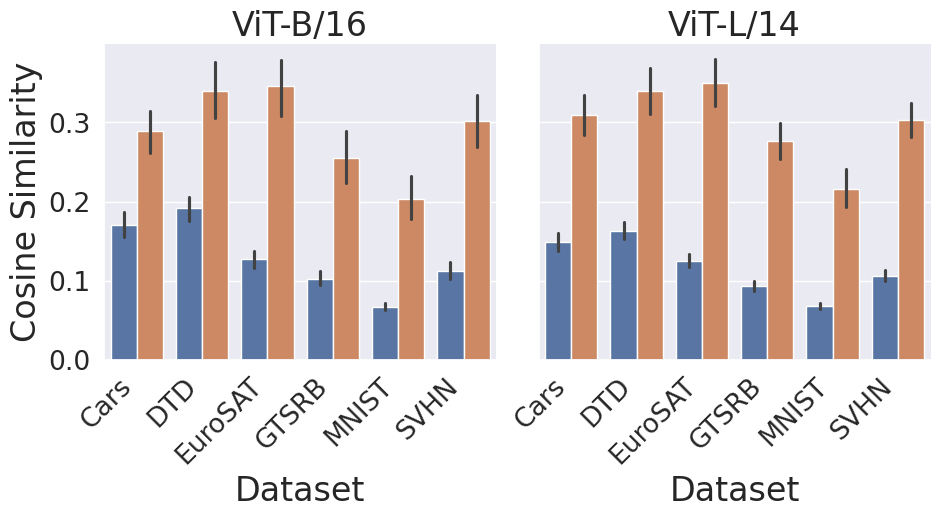

In [33]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"ViT-B-16": "ViT-B/16", "ViT-B-32": "ViT-B/32", "ViT-L-14": "ViT-L/14"}

df = pd.read_csv(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df = df[df["ft_method"] == "standard"]
df = df[df["method"] != "Zeros"]
df = df[df["method"] != "Random"]
df["model"] = df["model"].map(MODEL_MAP).fillna(df["model"])
df["cos_sim"] = (1 - df["error"])

g = sns.catplot(
    data=df,
    x="dataset",
    y="cos_sim",
    hue="method",
    col="model",
    kind="bar",
    legend=False,
    sharey=True,
    hue_order=["Identity", "EigenCov"],
    # palette = {"EigenCov": sns.color_palette()[0], "Identity": sns.color_palette()[1], "Random": sns.color_palette()[2]}
)

g.set_axis_labels("Dataset", "Cosine Similarity")
g.set_titles(col_template="{col_name}")
g.set_xticklabels(rotation=45, ha="right")
g.figure.savefig(
    f"../results/eigcov_estimation_error_vision_dataset_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

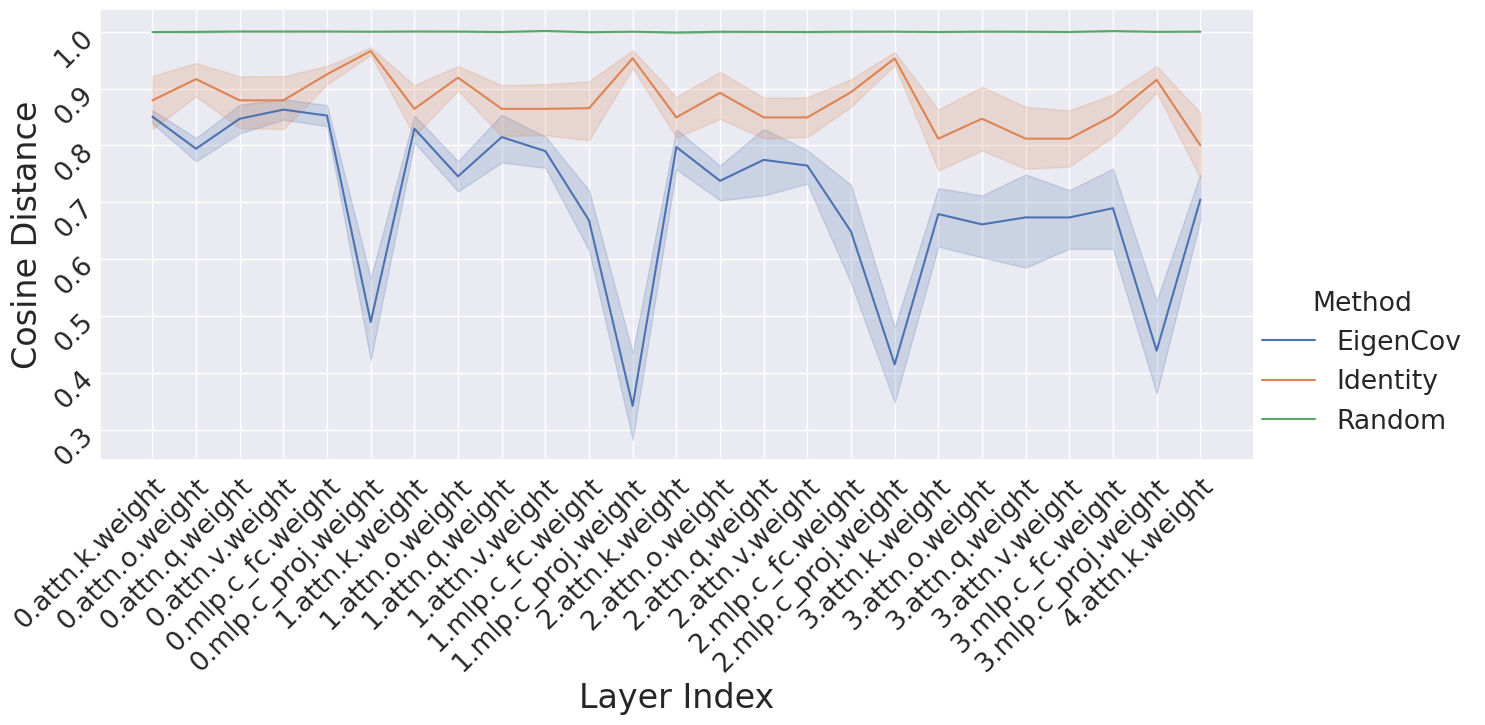

In [40]:
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

df = pd.read_csv(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df = df[df["ft_method"] == "standard"]
df = df[df["method"] != "Zeros"]
df = df[df["model"] == "ViT-B-16"]

# Re-index layers: natural sort by layer_name
def natural_sort_key(s):
    return [int(tok) if tok.isdigit() else tok for tok in re.split(r'(\d+)', s)]

sorted_layers = sorted(df["layer_name"].unique(), key=natural_sort_key)
layer_to_idx = {name: idx for idx, name in enumerate(sorted_layers)}
df["layer_idx"] = df["layer_name"].map(layer_to_idx).astype(int)

df = df[df["layer_idx"] < 25]
df['layer_abbrv'] = df['layer_name'].apply(lambda k: k.replace("model.visual.transformer.resblocks.", ""))
df = df.sort_values("layer_idx")

g = sns.relplot(
    data=df,
    x="layer_abbrv",
    y="error",
    hue="method",
    kind="line",
    legend="brief",
    facet_kws={"sharey": True},
    height=6,
    aspect=2.2,
    hue_order=["EigenCov", "Identity", "Random"],
)

g.set_axis_labels("Layer Index", "Cosine Distance")
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=45, ha='right', rotation_mode='anchor')

if g.legend:
    g.legend.set_title("Method")

## Fig. 1b: EigCov Estimation Error (Language)

In [ ]:
import sys
import os
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd

sys.path.append("..")
from src.language.task_vectors import LanguageNonLinearTaskVector

MODELS = ["t5-base", "t5-large"]
DATASETS = ["qasc", "wiki_qa", "quartz", "paws", "story_cloze", "winogrande", "wsc"]
FT_METHODS = ["standard"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
LOW_SAMPLE_COUNTS = [1, 10, 100, 500, 1000]
LOW_SAMPLE_BATCH_SIZE = 1
RESULTS_ROOT = "../results"
CHECKPOINTS_ROOT = "../checkpoints"
SAVE_PATH = os.path.join(RESULTS_ROOT, f"eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")

param_key_to_cov_key = lambda name: name.replace(".weight", "")

def dist_cos_noabs(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    cos_theta = torch.dot(a, b) / (a.norm() * b.norm())
    return (1 - cos_theta)

rows = []
for model_name in MODELS:
    results_dir = os.path.join(RESULTS_ROOT, model_name)
    checkpoint_dir = os.path.join(CHECKPOINTS_ROOT, model_name)

    for ft_method, dataset in product(FT_METHODS, DATASETS):
        cov_path = f"{results_dir}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_efull_ft{ft_method}/covariance_{dataset}.npz"
        if not os.path.exists(cov_path):
            print(f"Missing covariance: {cov_path}")
            continue
        covs = np.load(cov_path, allow_pickle=True)

        # Load low-sample covariances
        low_sample_covs = {}
        for ns in LOW_SAMPLE_COUNTS:
            ls_path = f"{results_dir}/covariances_strain_n{ns}_b{LOW_SAMPLE_BATCH_SIZE}_tsm_efull_ft{ft_method}/covariance_{dataset}.npz"
            if os.path.exists(ls_path):
                low_sample_covs[ns] = np.load(ls_path, allow_pickle=True)
            else:
                print(f"Missing low-sample covariance (n={ns}): {ls_path}")

        pretrained_checkpoint = f"{checkpoint_dir}/{dataset}/zeroshot.pt"
        finetuned_checkpoint = f"{checkpoint_dir}/{dataset}/finetuned.pt"
        task_vector = LanguageNonLinearTaskVector(
            pretrained_checkpoint,
            finetuned_checkpoint,
        )

        num_added = 0
        for k, m in task_vector.vector.items():
            kp = param_key_to_cov_key(k)
            if len(m.shape) != 2 or kp not in covs.keys():
                continue
            m = m.to(DEVICE)
            c = torch.from_numpy(covs[kp]).to(m.dtype).to(DEVICE)
            c_hat_ident = torch.eye(c.shape[0], c.shape[1], dtype=c.dtype, device=DEVICE)
            c_hat_ec = m.T @ m
            c_hat_rand = torch.randn_like(c, device=DEVICE)

            methods = [
                ("EigenCov", c_hat_ec),
                ("Random", c_hat_rand),
                ("Identity", c_hat_ident),
            ]
            for ns, ls_covs in low_sample_covs.items():
                if kp in ls_covs.keys():
                    c_hat_ls = torch.from_numpy(ls_covs[kp]).to(m.dtype).to(DEVICE)
                    methods.append((f"Cov (n={ns})", c_hat_ls))

            for method, c_hat in methods:
                rows.append({
                    "model": model_name, "dataset": dataset, "layer_name": k,
                    "layer_idx": num_added, "method": method,
                    "error": dist_cos_noabs(c, c_hat).item(), "ft_method": ft_method,
                })
            num_added += 1
            print(f"{model_name} | {ft_method} | {dataset} | layer {num_added} | {k.split('.')[-2]}")

df_lang = pd.DataFrame(rows)
df_lang.to_csv(SAVE_PATH, index=False)

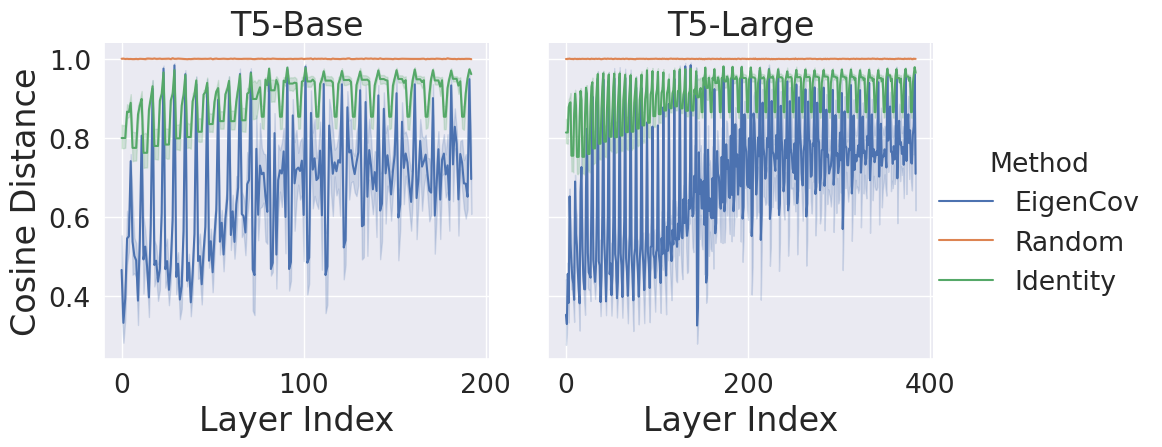

In [58]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"t5-base": "T5-Base", "t5-large": "T5-Large"}

df_lang = pd.read_csv(f"../results/eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df_lang = df_lang[df_lang["ft_method"] == "standard"]
df_lang = df_lang[df_lang["method"] != "Zeros"]
df_lang["model"] = df_lang["model"].map(MODEL_MAP).fillna(df_lang["model"])

g = sns.relplot(
    data=df_lang,
    x="layer_idx",
    y="error",
    hue="method",
    col="model",
    kind="line",
    legend="brief",
    facet_kws={"sharey": True, "sharex": False},
)

g.set_axis_labels("Layer Index", "Cosine Distance")
g.set_titles(col_template="{col_name}")
g.legend.set_title("Method")
g.figure.savefig(
    f"../results/eigcov_estimation_error_lang_layer_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

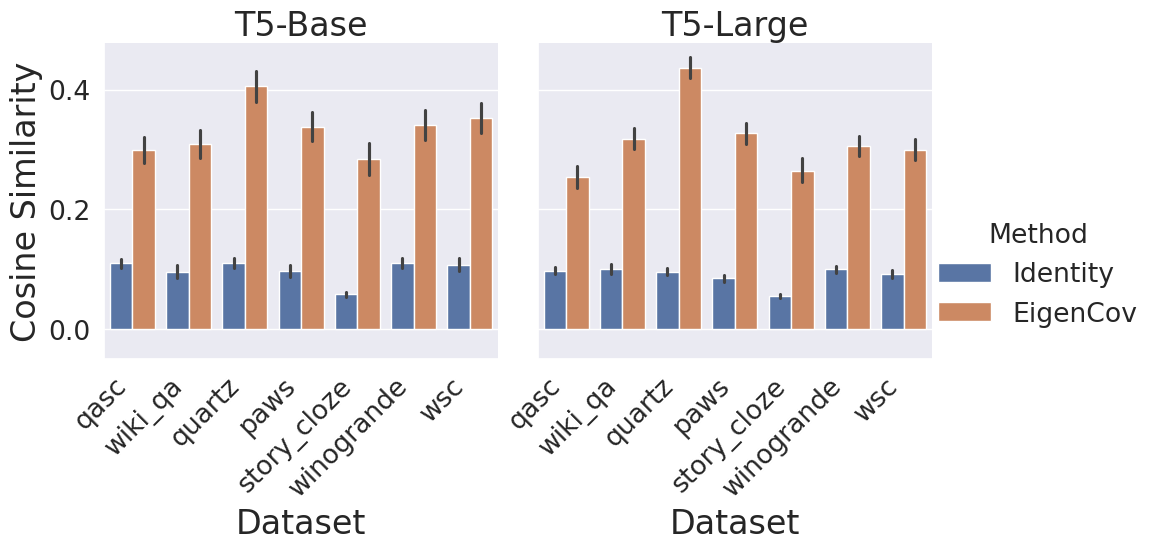

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10


sns.set_theme(
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

MODEL_MAP = {"t5-base": "T5-Base", "t5-large": "T5-Large"}

df_lang = pd.read_csv(f"../results/eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df_lang = df_lang[df_lang["ft_method"] == "standard"]
df_lang = df_lang[df_lang["method"] != "Zeros"]
df_lang = df_lang[df_lang["method"] != "Random"]
df_lang["model"] = df_lang["model"].map(MODEL_MAP).fillna(df_lang["model"])
df_lang["cos_sim"] = (1 - df_lang["error"])

g = sns.catplot(
    data=df_lang,
    x="dataset",
    y="cos_sim",
    hue="method",
    col="model",
    kind="bar",
    legend="brief",
    sharey=True,
    hue_order=["Identity", "EigenCov"],
)

g.set_axis_labels("Dataset", "Cosine Similarity")
g.set_titles(col_template="{col_name}")
g.legend.set_title("Method")
g.set_xticklabels(rotation=45, ha="right")
g.figure.savefig(
    f"../results/eigcov_estimation_error_lang_dataset_wise.pdf",
    dpi=300,
    bbox_inches="tight",
)

## Fig. 1c: EigCov Estimation Error (Combined)

/home/mila/m/marawan.gamal/scratch/eigcov/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/mila/m/marawan.gamal/scratch/eigcov/.venv/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)


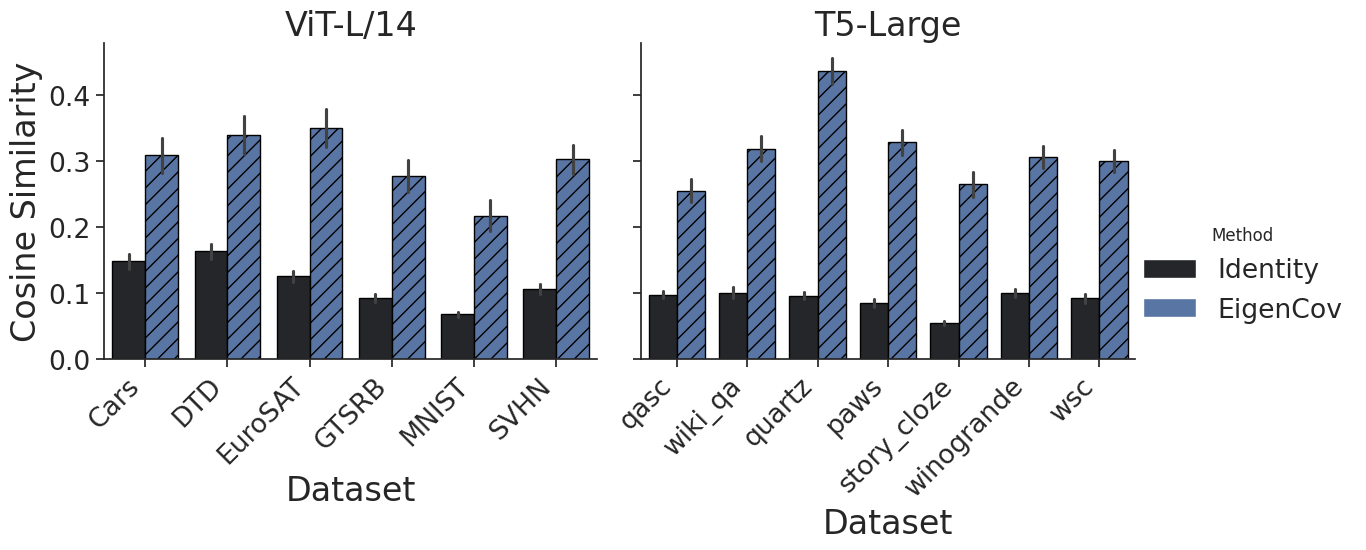

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

BATCH_SIZE, NUM_SAMPLES = 32, 10
VISION_MODELS = {"ViT-B-16": "ViT-B/16", "ViT-B-32": "ViT-B/32", "ViT-L-14": "ViT-L/14"}
LANG_MODELS = {"t5-base": "T5-Base", "t5-large": "T5-Large"}

def load_and_prep(path, model_map):
    df = pd.read_csv(path)
    df = df[(df["ft_method"] == "standard") & ~df["method"].isin(["Zeros", "Random"])]
    df["model"] = df["model"].map(model_map).fillna(df["model"])
    df["cos_sim"] = 1 - df["error"]
    return df

df = pd.concat([
    load_and_prep(f"../results/eigcov_estimation_error_vision_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv", VISION_MODELS),
    load_and_prep(f"../results/eigcov_estimation_error_lang_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv", LANG_MODELS),
], ignore_index=True)

df = df[df["model"].isin(["ViT-L/14", "T5-Large"])]

BASE_FONTSIZE = 24
sns.set_theme(style="ticks", rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

g = sns.FacetGrid(df, col="model", col_order=["ViT-L/14", "T5-Large"], sharey=True, sharex=False, height=5, aspect=1.2)
g.map_dataframe(sns.barplot, x="dataset", y="cos_sim", hue="method", hue_order=["Identity", "EigenCov"])

# Add hatching per hue group
hatches = [None, "//"]
for ax in g.axes.flat:
    for container, hatch in zip(ax.containers, hatches):
        for bar in container:
            bar.set_hatch(hatch)
            bar.set_edgecolor("black")

g.set_axis_labels("Dataset", "Cosine Similarity")
g.set_titles(col_template="{col_name}")
g.set_xticklabels(rotation=45, ha="right")
g.add_legend(title="Method")
g.figure.savefig("../results/eigcov_estimation_error_combined.pdf", dpi=300, bbox_inches="tight")


## Fig. 2a: (Assumption I) Cross-term Error

In [ ]:
import pandas as pd
import torch
import os

def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.dot(a.flatten(), b.flatten()) / (a.norm() * b.norm())

# root_dir = "../checkpoints-gcm-e2/ViT-B-16/"
root_dir = "../checkpoints-accum-e2-v2-2026-06-15/ViT-B-16/max_steps_10"
DATASETS = [
    "Cars",
    "DTD",
    "EuroSAT",
    "GTSRB",
    "MNIST",
    "RESISC45",
    "SUN397",
    "SVHN",
]

errors = []
for d in DATASETS:
    for filename in os.listdir(os.path.join(root_dir, d + "Val")):
        if not "grad_cross" in filename:
            continue
        layer_name = filename.replace(".pt", "").replace("grad_cross_matrix_model_visual_transformer_resblocks_", "")
        gcm = torch.load(os.path.join(root_dir, d + "Val", filename))
        # print(gcm['gbar'].shape, gcm['sbar'].shape)
        cosim = cosine_similarity(gcm['gbar'].T @ gcm['gbar'], gcm['sbar'])
        errors.append({"dataset": d, "layer_name": layer_name, "cosine_similarity": cosim.item()})

df = pd.DataFrame(errors)

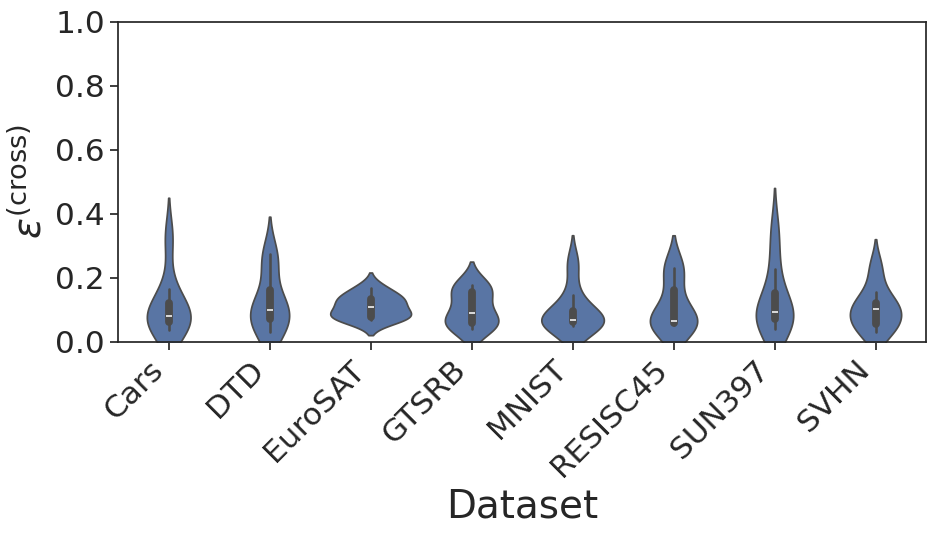

In [71]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# sns.set_theme()

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = f"../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)
df = pd.DataFrame(errors)

# Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="dataset", y="angular_distance")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\epsilon^{\mathrm{(cross)}}$")
plt.xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_cross.pdf"), bbox_inches="tight")

## Fig. 2b: (Assumption II) Correlation Error


In [72]:
import pandas as pd
import torch
import os

def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.dot(a.flatten(), b.flatten()) / (a.norm() * b.norm())

# root_dir = "../checkpoints-gcm-e2/ViT-B-16/"
root_dir = "../checkpoints-accum-e2-v2-2026-06-15/ViT-B-16/max_steps_10"
DATASETS = [
    "Cars",
    "DTD",
    "EuroSAT",
    "GTSRB",
    "MNIST",
    "RESISC45",
    "SUN397",
    "SVHN",
]

errors = []
for d in DATASETS:
    for filename in os.listdir(os.path.join(root_dir, d + "Val")):
        if not "grad_cross" in filename:
            continue
        layer_name = filename.replace(".pt", "").replace("grad_cross_matrix_model_visual_transformer_resblocks_", "")
        gcm = torch.load(os.path.join(root_dir, d + "Val", filename))
        # print(gcm['stilde'].shape, gcm['sbar'].shape)
        cosim = cosine_similarity(gcm['sbar'], gcm['stilde'])
        errors.append({"dataset": d, "layer_name": layer_name, "cosine_similarity": cosim.item()})

df = pd.DataFrame(errors)

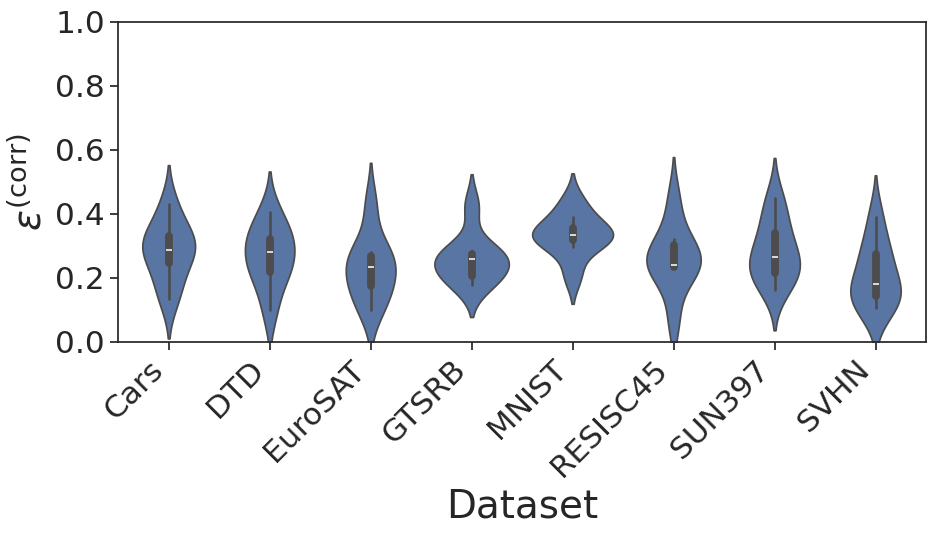

In [73]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = "../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)
df = pd.DataFrame(errors)

# Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 


plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="dataset", y="angular_distance")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\epsilon^{\mathrm{(corr)}}$")
plt.xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_corr.pdf"), bbox_inches="tight")

## Fig. 2c: (Assumption III)  Drift Error

In [74]:
import pandas as pd
import torch
import os

def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.dot(a.flatten(), b.flatten()) / (a.norm() * b.norm())

root_dir = "../checkpoints-accum-e2-v2-2026-06-15/ViT-B-16/max_steps_10"
covs_dir = f"{root_dir}/covariances_strain_n10_b32_tsm_attnsplit_efull_ftstandard"
DATASETS = [
    "Cars",
    "DTD",
    "EuroSAT",
    "GTSRB",
    "MNIST",
    "RESISC45",
    "SUN397",
    "SVHN",
]


file2layer = lambda x: "image_encoder." + x.replace(".pt", "").replace("grad_cross_matrix_", "").replace("_", ".")
errors = []
for d in DATASETS:
    covs = np.load(f"{covs_dir}/covariance_{d}.npz")
    for filename in os.listdir(os.path.join(root_dir, d + "Val")):
        if not "grad_cross" in filename:
            continue
        layer_name = filename.replace(".pt", "").replace("grad_cross_matrix_model_visual_transformer_resblocks_", "")
        gcm = torch.load(os.path.join(root_dir, d + "Val", filename))
        cov = covs.get(file2layer(filename), None)
        if cov is None:
            continue
        cov = torch.from_numpy(cov)
        cosim = cosine_similarity(gcm['stilde'], cov)
        errors.append({"dataset": d, "layer_name": layer_name, "cosine_similarity": cosim.item(), "type": "stilde"})

df = pd.DataFrame(errors)

In [ ]:
# # DEBUG
# rand = torch.randn_like(gcm['stilde']) * 0.00001
# print(cov.norm(), gcm['stilde'].norm(), rand.norm())
# print(cosine_similarity(gcm['stilde'], rand)) 
# print(cosine_similarity(gcm['stilde'], cov))
# tensor(31755.3848) tensor(0.0238) tensor(0.0077)
# tensor(-0.0020)
# tensor(0.9984)

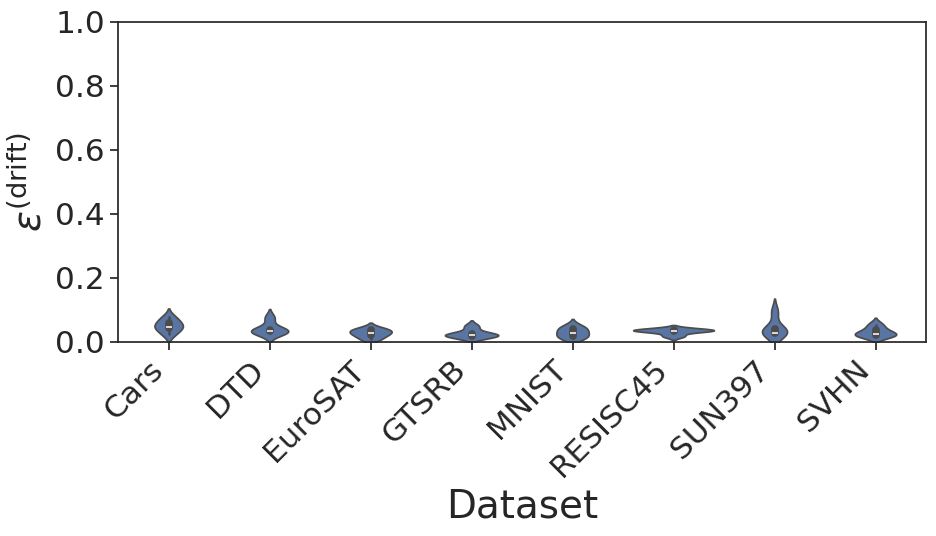

In [75]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

BASE_FONTSIZE = 28
sns.set_theme( 
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

RESULTS_DIR = f"../results/ViT-B-16"
os.makedirs(RESULTS_DIR, exist_ok=True)
df = pd.DataFrame(errors)

# Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="dataset", y="angular_distance")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\epsilon^{\mathrm{(drift)}}$")
plt.xlabel("Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_drift.pdf"), bbox_inches="tight")

## Fig. 4a: (Assumption II)  Correlation between Gradients and Activations


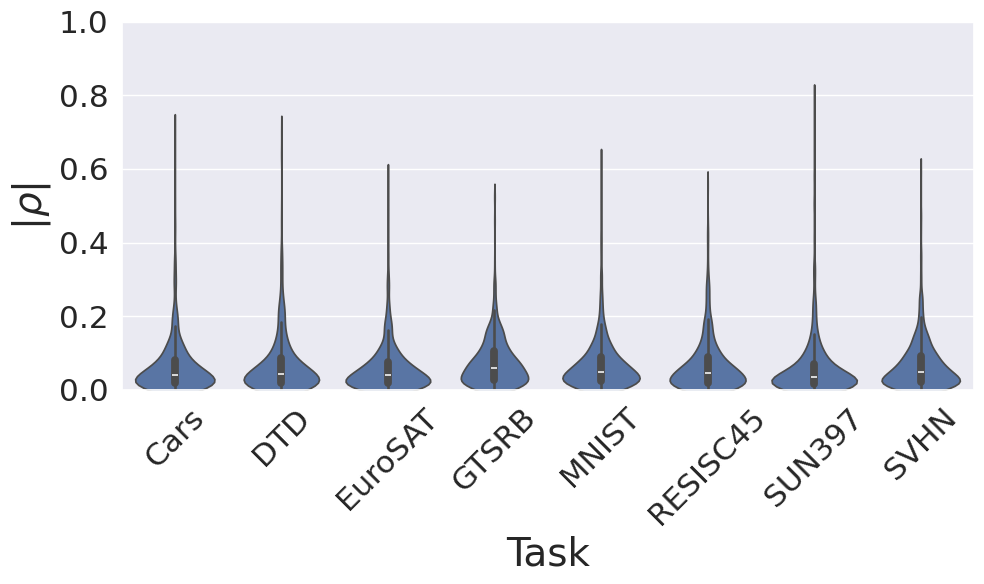


Summary Statistics (all points):
           mean    std    50%    max
task                                
Cars      0.065  0.081  0.041  0.706
DTD       0.070  0.083  0.044  0.700
EuroSAT   0.061  0.070  0.041  0.575
GTSRB     0.076  0.068  0.059  0.524
MNIST     0.070  0.072  0.049  0.616
RESISC45  0.068  0.073  0.045  0.554
SUN397    0.060  0.082  0.034  0.786
SVHN      0.067  0.068  0.047  0.592

Overall mean |ρ|: 0.067
% of all correlations < 0.1: 79.7%


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from itertools import product

sns.set_theme()
BASE_FONTSIZE=28

model = "ViT-B-16"
batch_size = 1
num_samples = 100
num_indices = 32
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ft_methods = ["standard"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task, ft_method in product(tasks, ft_methods):
    corr_dir = f"../results-v1/{model}/correlations_b{batch_size}_n{num_samples}_k{num_indices}_ft{ft_method}"
    path = f"{corr_dir}/correlation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    # remove "g_sq/" prefix
    layers = [k[5:] for k in data.files if k.startswith("g_sq/")]
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        N_samples, N_indices = aat.shape
        for idx_i in range(N_indices):
            rho = np.abs(corr(g, aat[:, idx_i]))
            rows.append({'task': task, 'layer': l, 'layer_idx': idx_l, 'entry_idx': idx_i, 'rho': rho, 'ft_method': ft_method})

df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x="task", y="rho", ax=ax)

ax.set_xlabel("Task", fontsize=BASE_FONTSIZE)
ax.set_ylabel(r"$|\rho|$", fontsize=BASE_FONTSIZE)
ax.tick_params(axis='x', labelsize=BASE_FONTSIZE * 0.8, rotation=45)
ax.tick_params(axis='y', labelsize=BASE_FONTSIZE * 0.8)
# ax.legend(title="FT Method", fontsize=BASE_FONTSIZE * 0.8, title_fontsize=BASE_FONTSIZE * 0.8)
ax.set_ylim(0, 1.0)

plt.tight_layout()
# plt.savefig(f"../results-v1/correlation_violin.pdf", dpi=300, bbox_inches='tight')
# print(f"Saved to: ../results-v1/{model}/correlation_violin.pdf")
plt.show()

# Print summary
print("\nSummary Statistics (all points):")
print(df.groupby('task')['rho'].describe()[['mean', 'std', '50%', 'max']].round(3).to_string())
print(f"\nOverall mean |ρ|: {df['rho'].mean():.3f}")
print(f"% of all correlations < 0.1: {(df['rho'] < 0.1).mean() * 100:.1f}%")

## Fig. 4b: (Assumption III) Covariance Stationarity

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
MAX_CKPT = 10


def cosine_similarity(A, B):
    a, b = torch.tensor(A).flatten().float(), torch.tensor(B).flatten().float()
    return (torch.dot(a, b) / (a.norm() * b.norm())).item()

# Find all checkpoint dirs and extract their numbers
ckpt_dirs = sorted(
    (int(d.split("checkpoint_")[-1]), d)
    for d in os.listdir(RESULTS_DIR)
    if "checkpoint_" in d and "covariance" in d
)[:MAX_CKPT]

ref_num, ref_dir = ckpt_dirs[-1]
print(f"Checkpoints: {[n for n, _ in ckpt_dirs]}, reference: {ref_num}")

rows = []
for dataset in tqdm(DATASETS, desc="Datasets"):
    ref = np.load(f"{RESULTS_DIR}/{ref_dir}/covariance_{dataset}.npz", allow_pickle=True)
    covs_accum = dict()

    for ckpt_num, ckpt_dir in tqdm(ckpt_dirs, desc=dataset, leave=False):
        path = f"{RESULTS_DIR}/{ckpt_dir}/covariance_{dataset}.npz"
        if not os.path.exists(path):
            continue
        covs = np.load(path, allow_pickle=True)
        for layer in ref.files:
            if layer in covs and covs[layer].ndim == 2:
                if layer not in covs_accum:
                    covs_accum[layer] = np.zeros_like(covs[layer])
                covs_accum[layer] += covs[layer]
                rows.append({
                    "checkpoint": ckpt_num,
                    "dataset": dataset,
                    "layer": layer,
                    "cosine_similarity": cosine_similarity(covs[layer], ref[layer]),
                    "cosine_similarity_accum": cosine_similarity(covs_accum[layer], ref[layer]),
                })

df = pd.DataFrame(rows)
df.to_csv(f"{RESULTS_DIR}/covariance_stationarity.csv", index=False)
print(df.groupby("checkpoint")["cosine_similarity"].mean())

Checkpoints: [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800], reference: 1800


Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

Cars:   0%|          | 0/10 [00:00<?, ?it/s]

DTD:   0%|          | 0/10 [00:00<?, ?it/s]

EuroSAT:   0%|          | 0/10 [00:00<?, ?it/s]

GTSRB:   0%|          | 0/10 [00:00<?, ?it/s]

MNIST:   0%|          | 0/10 [00:00<?, ?it/s]

RESISC45:   0%|          | 0/10 [00:00<?, ?it/s]

SUN397:   0%|          | 0/10 [00:00<?, ?it/s]

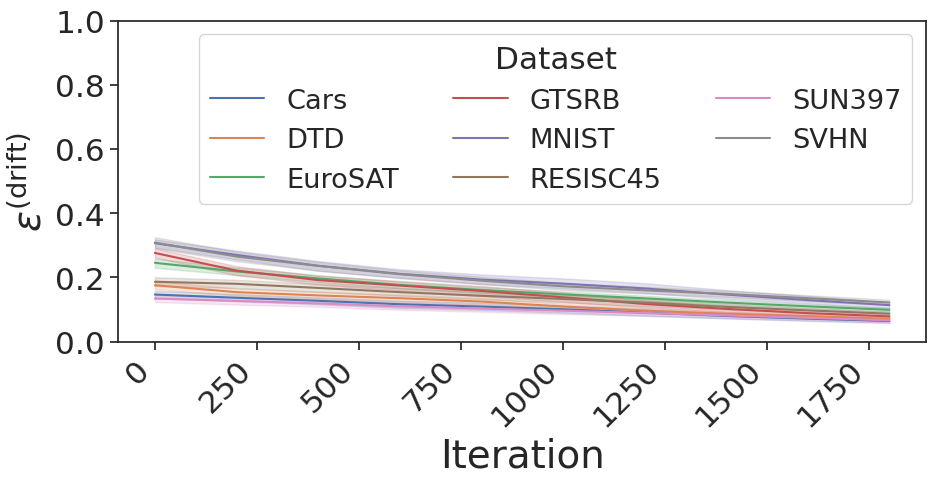

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = f"../results/ViT-B-16"

df = pd.read_csv(f"{RESULTS_DIR}/covariance_stationarity.csv")
df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi 
df["angular_distance_accum"] = np.arccos(df["cosine_similarity_accum"].clip(-1.0, 1.0)) / np.pi 


BASE_FONTSIZE = 28
sns.set_theme(
    style="ticks",
    rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.7,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

plt.figure(figsize=(10, 5.5))
sns.lineplot(data=df, x="checkpoint", y="angular_distance_accum", hue="dataset")
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.ylabel(r"$\epsilon^{\mathrm{(drift)}}$")
plt.xlabel("Iteration")
plt.legend(title="Dataset", loc="upper right", ncol=3, frameon=True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "angular_distance_accum_drift.pdf"), bbox_inches="tight")
plt.savefig("angular_distance_accum_drift.pdf", bbox_inches="tight")

## Fig. 5: Accuracy vs. Number of Samples used for Covariance Estimation

In [64]:
import json
import re
import pandas as pd

with open("../results-v1/results.jsonl") as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())

rm = df[df["merge_func"] == "regmean"].copy()
rm = rm[['model', 'finetuning_mode', 'cov_dir', 'test_avg_top1']]
display(rm)
# rm["n_batches"] = rm["cov_dir"].str.extract(r"_n(\d+)_")[0].astype(int)
# rm["batch_size"] = rm["cov_dir"].str.extract(r"_b(\d+)_")[0].astype(int)
# rm["n_samples"] = rm["n_batches"] * rm["batch_size"]
# display(rm[["model", "finetuning_mode", "n_batches", "batch_size", "n_samples", "test_avg_top1", "test_avg_normalized_top1"]])

,model,finetuning_mode,cov_dir,test_avg_top1
1,ViT-B-16,lora,results/ViT-B-16/covariances_strain_n10_b32_ts...,0.803967
12,ViT-B-32,lora,results/ViT-B-32/covariances_strain_n10_b32_ts...,0.762208
37,ViT-B-16,standard,results/ViT-B-16/covariances_strain_n10_b32_ts...,0.870506
38,ViT-B-32,standard,results/ViT-B-32/covariances_strain_n10_b32_ts...,0.831229
39,ViT-L-14,standard,results/ViT-L-14/covariances_strain_n10_b32_ts...,0.901043
45,ViT-L-14,lora,results/ViT-L-14/covariances_strain_n10_b32_ts...,0.869147
53,t5-base,standard,results/t5-base/covariances_strain_n10_b32_tsm...,0.745286
54,t5-large,standard,results/t5-large/covariances_strain_n10_b32_ts...,0.808429
65,t5-base,lora,results/t5-base/covariances_strain_n10_b32_tsm...,0.739857
69,ViT-B-16,standard,results/ViT-B-16/covariances_eigcov_k1000_ftst...,0.794086


In [2]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
with open("../results/results.jsonl") as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())

# Parse n_samples from cov_dir string
df["n_batches"] = df["cov_dir"].str.extract(r"_n(\d+)_")[0].astype("Int64")
df["batch_size"] = df["cov_dir"].str.extract(r"_b(\d+)_")[0].astype("Int64")
df["n_samples"] = df["n_batches"] * df["batch_size"]
df["cov_estimator"] = df["cov_dir"].str.extract(r"_e(sampled|full)")[0]                                                                                                 
df["cov_attn"] = df["cov_dir"].str.extract(r"_attn(split|None)")[0] 

# Filter: keep only important columns
df = df[["model", "merge_func", "finetuning_mode", "n_samples", "n_batches", "batch_size", "cov_estimator", "cov_attn", "test_avg_top1"]]
# Filter: keep only RegMean and EigCov
df = df[df["merge_func"].isin(["regmean", "eigcov"])]
# Filter: keep only ViT-B-16
df = df[df["model"] == "ViT-B-16"]
# Filter: keep only standard finetuning
df = df[df["finetuning_mode"] == "standard"]
# Make many rows for EigCov
eigcov_row = df[df["merge_func"] == "eigcov"].iloc[0].copy()
df = df[df["merge_func"] != "eigcov"]
for n in [1, 10, 100, 500, 1000]:
    eigcov_row["n_samples"] = n
    eigcov_row["batch_size"] = 1
    df = pd.concat([df, eigcov_row.to_frame().T], ignore_index=True)
# Filter: keep only batch size 1
df = df[(df["batch_size"] == 1)]
# Display
display(df)

# df = df[df["merge_func"].isin(["regmean", "eigcov"]) & (df["model"] == "ViT-B-16")]
# df["Method"] = df["merge_func"].map({"regmean": "RegMean", "eigcov": "EigCov"})

# # Filter and rename
# print(df[df["Method"] == "EigCov"][["Model", "Method", "n", "batch_size", "Accuracy", "merge_func", "cov_dir"]])

# df = df[(df["batch_size"] == 1) | (df["Method"] == "EigCov")]
# df = df.rename(columns={"model": "Model", "test_avg_top1": "Accuracy", "n_samples": "n"})
# df = df[["Model", "Method", "n", "Accuracy"]]

# # Replicate EigCov across RegMean n values for flat reference line
# n_values = sorted(df.loc[df["Method"] == "RegMean", "n"].unique())
# eigcov_flat = df[df["Method"] == "EigCov"].drop(columns="n").merge(
#     pd.DataFrame({"n": n_values}), how="cross"
# )
# df = pd.concat([df[df["Method"] == "RegMean"], eigcov_flat], ignore_index=True)
# display(df)

# sns.set_theme()
# sns.lineplot(data=df, x="n_samples", y="test_avg_top1", hue="model", style="merge_func")
#             #  dashes={"RegMean": "", "EigCov": (4, 2)})
# plt.savefig("../results/acc_vs_n.pdf", dpi=300, bbox_inches="tight")
# plt.show()

/tmp/ipykernel_1499501/1312345065.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, eigcov_row.to_frame().T], ignore_index=True)
/tmp/ipykernel_1499501/1312345065.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, eigcov_row.to_frame().T], ignore_index=True)
/tmp/ipykernel_1499501/1312345065.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty o

,model,merge_func,finetuning_mode,n_samples,n_batches,batch_size,cov_estimator,cov_attn,test_avg_top1
3,ViT-B-16,regmean,standard,1,1,1,full,split,0.740815
4,ViT-B-16,regmean,standard,10,10,1,full,split,0.820168
5,ViT-B-16,regmean,standard,100,100,1,full,split,0.856086
6,ViT-B-16,regmean,standard,500,500,1,full,split,0.860047
7,ViT-B-16,regmean,standard,1000,1000,1,full,split,0.860271
8,ViT-B-16,regmean,standard,1,1,1,full,split,0.74606
9,ViT-B-16,regmean,standard,10,10,1,full,split,0.798364
10,ViT-B-16,regmean,standard,100,100,1,full,split,0.820557
11,ViT-B-16,regmean,standard,500,500,1,full,split,0.821978
12,ViT-B-16,regmean,standard,1000,1000,1,full,split,0.822465


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Data ─────────────────────────────────────────────────────────────────
N = [1, 10, 25, 50, 75, 200, 320, 500]

RESULTS = {
    # ("ViT-B-16", "RegMean"): [0.728, 0.824, 0.847, 0.863, 0.864, 0.871, 0.871, 0.875],
    # ("ViT-B-16", "EigCov"):  [0.87] * len(N),
    ("T5-Large", "RegMean"): [...],
    ("T5-Large", "EigCov"):  [...],
}
# ─────────────────────────────────────────────────────────────────────────

df = pd.DataFrame([
    {"Model": m, "Method": mt, "n": n, "Accuracy": a}
    for (m, mt), accs in RESULTS.items()
    for n, a in zip(N, accs)
])
sns.set_theme()
sns.lineplot(data=df, x="n", y="Accuracy", hue="Model", style="Method",
             dashes={"RegMean": "", "EigCov": (4, 2)}, markers=True)
plt.savefig("../results/acc_vs_n.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Fig. 6: RegMean vs. EigCov estimation

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
FT_METHOD = "standard"
BATCH_SIZE = 1
N_VALS = [1, 10, 100, 500, 1000]
N_MAX = max(N_VALS)
K_VALS = [8, 32, 64]
TASKS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")

rows = []
for task in tqdm(TASKS, desc="Tasks"):
    target_path = f"{RESULTS_DIR}/covariances_strain_n{N_MAX}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
    if not os.path.exists(target_path):
        print(f"Missing target: {target_path}")
        continue
    target_covs = np.load(target_path, allow_pickle=True)

    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/finetuned.pt"
    tv = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)

    layers = [(k, m) for k, m in tv.vector.items() if len(m.shape) == 2 and param_name_to_module_name(k) in target_covs]
    for key, m in tqdm(layers, desc=f"  {task} layers", leave=False):
        kp = param_name_to_module_name(key)
        c_target = torch.from_numpy(target_covs[kp]).float()
        c_ec = (m.T @ m).float()

        for n in N_VALS:
            cov_path = f"{RESULTS_DIR}/covariances_strain_n{n}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
            if not os.path.exists(cov_path):
                print(f"Missing: {cov_path}")
                continue
            covs = np.load(cov_path, allow_pickle=True)
            if kp not in covs:
                continue
            c_rm = torch.from_numpy(covs[kp]).float()

            for kk in K_VALS:
                rows.append({"task": task, "layer": key, "n": n, "k": kk, "method": "RegMean", "error": dist_fn(c_rm, c_target, kk)})
                rows.append({"task": task, "layer": key, "n": n, "k": kk, "method": "EigenCov", "error": dist_fn(c_ec, c_target, kk)})

df_est = pd.DataFrame(rows)
print(df_est.groupby(["method", "n", "k"])["error"].mean().unstack("method"))


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import sys

# Add src to path
sys.path.append("..")

from src.vision.task_vectors import NonLinearTaskVector

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
FT_METHOD = "standard"
BATCH_SIZE = 1
N_VALS = [1, 10, 100, 500, 1000]
N_MAX = max(N_VALS)
TASKS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")

def frob_error(C, C_target):
    """||C_target - C||_F / ||C_target||_F"""
    diff = torch.linalg.norm(C_target - C, ord="fro")
    norm = torch.linalg.norm(C_target, ord="fro")
    return (diff / norm).item() if norm > 1e-12 else float("nan")

rows = []
for task in tqdm(TASKS, desc="Tasks"):
    # Load target covariance (largest n)
    target_path = f"{RESULTS_DIR}/covariances_strain_n{N_MAX}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
    if not os.path.exists(target_path):
        print(f"Missing target: {target_path}")
        continue
    target_covs = np.load(target_path, allow_pickle=True)

    # Load task vector and compute c_ec = M.T @ M (constant across n)
    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/finetuned.pt"
    tv = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)

    layers = [(k, m) for k, m in tv.vector.items() if len(m.shape) == 2 and param_name_to_module_name(k) in target_covs]
    for k, m in tqdm(layers, desc=f"  {task} layers", leave=False):
        kp = param_name_to_module_name(k)
        c_target = torch.from_numpy(target_covs[kp]).float()
        c_ec = (m.T @ m).float()
        ec_err = frob_error(c_ec, c_target)

        for n in N_VALS:
            cov_path = f"{RESULTS_DIR}/covariances_strain_n{n}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
            if not os.path.exists(cov_path):
                print(f"Missing: {cov_path}")
                continue
            covs = np.load(cov_path, allow_pickle=True)
            if kp not in covs:
                continue
            c_rm = torch.from_numpy(covs[kp]).float()
            rows.append({"task": task, "layer": k, "n": n, "method": "RegMean", "error": frob_error(c_rm, c_target)})
            rows.append({"task": task, "layer": k, "n": n, "method": "EigenCov", "error": ec_err})

df_est = pd.DataFrame(rows)
print(df_est.groupby(["method", "n"])["error"].mean().unstack("method"))


Tasks:   0%|          | 0/8 [00:00<?, ?it/s]

  Cars layers:   0%|          | 0/24 [00:00<?, ?it/s]

  DTD layers:   0%|          | 0/24 [00:00<?, ?it/s]

  EuroSAT layers:   0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
BASE_FONTSIZE = 24

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

df_plot = df_est.groupby(["method", "n", "k"])["error"].mean().reset_index()

# EigenCov is constant across n; plot as horizontal dashed line per k facet
palette = {"RegMean": sns.color_palette()[0], "EigenCov": sns.color_palette()[1]}

g = sns.relplot(
    data=df_plot[df_plot["method"] == "RegMean"],
    x="n", y="error",
    col="k",
    kind="line",
    markers=True,
    label="RegMean",
    color=palette["RegMean"],
    facet_kws={"sharey": False, "legend_out": True},
)

# Add EigenCov as a horizontal dashed line per facet
for ax, kk in zip(g.axes.flat, K_VALS):
    ec_err = df_plot[(df_plot["method"] == "EigenCov") & (df_plot["k"] == kk)]["error"].mean()
    ax.axhline(ec_err, linestyle="--", color=palette["EigenCov"], label="EigenCov")
    ax.set_xscale("log")
    ax.set_xticks(N_VALS)
    ax.set_xticklabels(N_VALS, rotation=45)

g.axes.flat[0].legend(title="Method")
g.set_axis_labels("Number of Samples ($n$)", "Grassmann Distance")
g.set_titles(col_template="k = {col_name}")

g.figure.savefig(f"{RESULTS_DIR}/regmean_vs_eigcov_grassmann_vs_n.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Table 1 & 2. Merging Performance on Standard and LoRA finetuning

In [26]:
import json
import pandas as pd


METRIC = "test_avg_top1"
COLS = ["T5-Base", "T5-Large", "ViT-B/16", "ViT-B/32", "ViT-L/14"]

MODEL_MAP = {
    "t5-base": "T5-Base",
    "t5-large": "T5-Large",
    "T5-Base": "T5-Base",
    "T5-Large": "T5-Large",
    "ViT-B-16": "ViT-B/16",
    "ViT-B-32": "ViT-B/32",
    "ViT-L-14": "ViT-L/14",
}

METHOD_MAP = {
    "mean": "Average",
    "sum": "TA",
    "regmean": "RegMean",
    "eigcov": "EigenCov",
    "tsv": "TSV",
    "isoc_mean": "ISO-C",
    "knots_tsv": "KNOTS-TSV",
    "knots_isoc_mean": "KNOTS-ISO-C",
    # Add eigcov with reg
    "eigcov_01": "EigenCov-01",
    "eigcov_02": "EigenCov-02",
    "eigcov_03": "EigenCov-03",
    "eigcov_04": "EigenCov-04",
    "eigcov_05": "EigenCov-05",
    "eigcov_06": "EigenCov-06",
    "eigcov_07": "EigenCov-07",
    "eigcov_08": "EigenCov-08",
    "eigcov_09": "EigenCov-09",
    "eigcov_10": "EigenCov-10",
}

DATA_FREE = {
    "RegMean": True,
    "EigenCov": False,
    "TSV": False,
    "ISO-C": False,
    "KNOTS-TSV": False,
    "KNOTS-ISO-C": False,
}

def get_pivoted_table(ft_mode='lora'):

    with open("../results/results.jsonl", "r") as f:
        df = pd.DataFrame(json.loads(line) for line in f if line.strip())

    # with open("../results/results-hpopt.jsonl", "r") as f:
    #     df = pd.DataFrame(json.loads(line) for line in f if line.strip())

    df = df.copy()
    df["Model"] = df["model"].map(MODEL_MAP).fillna(df["model"])
    df["Method"] = df["merge_func"].map(METHOD_MAP).fillna(df["merge_func"])

    # Filter use only on standard finetuning
    df = df[df['finetuning_mode'] == ft_mode]

    best = df.groupby(["Method", "Model"], as_index=False)[METRIC].max()
    tbl = best.pivot(index="Method", columns="Model", values=METRIC).reindex(columns=COLS)

    # sort by acc on the ViT-B/16 model (descending)
    tbl = tbl.assign(sort_key=tbl["T5-Base"]).sort_values("sort_key", ascending=True).drop(columns="sort_key")

    tbl.insert(0, "Data-free", [r"\xmark" if DATA_FREE.get(m, False) else r"\cmark" for m in tbl.index])
    tbl.insert(0, "Method", [rf"\textsc{{{m}}}" for m in tbl.index])

    for c in COLS:
        tbl[c] = tbl[c].map(lambda x: "" if pd.isna(x) else f"{100*x:.1f}")

    return tbl


from IPython.display import display, Markdown
from IPython.display import display, HTML


def print_nice_latex_table(title, tbl):
    display(Markdown(f"### {title}"))
    display(Markdown("```latex\n" + tbl.reset_index(drop=True).to_latex(index=False, escape=False) + "\n```"))

def styled_table(tbl, title):
    styled = tbl.style.set_caption(title).format(precision=1).set_table_styles([
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('font-weight', 'bold'), ('font-size', '1.1em')]}
    ])  
    display(styled)

# Print latex tables
print_nice_latex_table("Standard", get_pivoted_table(ft_mode='standard'))
print_nice_latex_table("LoRA", get_pivoted_table(ft_mode='lora'))

# # # Print styled tables
# styled_table(get_pivoted_table(ft_mode='standard'), "Standard Finetuning Results")
# display(HTML("<hr style='margin: 2em 0;' />"))
# styled_table(get_pivoted_table(ft_mode='lora'), "LoRA Finetuning Results")


### Standard

```latex
\begin{tabular}{lllllll}
\toprule
Method & Data-free & T5-Base & T5-Large & ViT-B/16 & ViT-B/32 & ViT-L/14 \\
\midrule
\textsc{TA} & \cmark & 60.2 & 60.5 &  &  &  \\
\textsc{Average} & \cmark & 64.7 & 54.6 &  &  &  \\
\textsc{ISO-C} & \cmark & 67.4 & 63.5 &  &  &  \\
\textsc{RegMean} & \xmark & 72.5 & 79.4 & 86.1 & 83.0 & 90.2 \\
\textsc{TSV} & \cmark & 73.1 & 76.8 &  &  &  \\
\textsc{EigenCov} & \cmark & 74.0 & 79.8 & 88.0 & 82.7 & 92.2 \\
\textsc{EigenCov-01} & \cmark &  &  & 62.4 &  &  \\
\textsc{EigenCov-02} & \cmark &  &  & 59.9 &  &  \\
\textsc{EigenCov-05} & \cmark &  &  & 57.8 &  &  \\
\textsc{KNOTS-ISO-C} & \cmark &  &  & 64.4 & 55.5 & 85.1 \\
\textsc{KNOTS-TSV} & \cmark &  &  & 78.9 & 70.0 & 88.3 \\
\textsc{eigcov_001} & \cmark &  &  & 73.2 &  &  \\
\textsc{eigcov_005} & \cmark &  &  & 65.2 &  &  \\
\textsc{eigcov_lstsq} & \cmark &  &  & 85.5 & 79.9 & 91.2 \\
\textsc{wudi_00001} & \cmark &  &  & 88.2 & 83.2 & 92.0 \\
\textsc{wudi_0001} & \cmark &  &  & 88.6 & 84.5 & 92.0 \\
\textsc{wudi_001} & \cmark &  &  & 85.5 &  &  \\
\textsc{wudi_005} & \cmark &  &  & 79.3 &  &  \\
\textsc{wudi_01} & \cmark &  &  & 75.3 &  &  \\
\textsc{wudi_02} & \cmark &  &  & 71.1 &  &  \\
\bottomrule
\end{tabular}

```

### LoRA

```latex
\begin{tabular}{lllllll}
\toprule
Method & Data-free & T5-Base & T5-Large & ViT-B/16 & ViT-B/32 & ViT-L/14 \\
\midrule
\textsc{Average} & \cmark &  &  & 64.3 & 56.8 & 72.4 \\
\textsc{EigenCov} & \cmark &  &  & 78.6 & 74.6 & 86.1 \\
\textsc{ISO-C} & \cmark &  &  & 57.5 & 50.4 & 66.8 \\
\textsc{KNOTS-ISO-C} & \cmark &  &  & 74.9 & 70.4 & 83.6 \\
\textsc{KNOTS-TSV} & \cmark &  &  & 74.8 & 69.6 & 83.4 \\
\textsc{RegMean} & \xmark &  &  & 80.3 & 76.5 & 86.9 \\
\textsc{TA} & \cmark &  &  & 66.1 & 53.5 & 77.6 \\
\textsc{TSV} & \cmark &  &  & 78.4 & 73.0 & 85.4 \\
\bottomrule
\end{tabular}

```

In [4]:
with open("../results/results-hpopt.jsonl", "r") as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())
df[["model", "merge_func", "finetuning_mode", "test_avg_top1"]]


,model,merge_func,finetuning_mode,test_avg_top1
0,ViT-B-16,sum,standard,0.761121
1,ViT-B-32,sum,standard,0.696859
2,ViT-L-14,sum,standard,0.842962


## MISC

In [ ]:
def dist_gm_proj(A, B, k):
    U_a, _, _ = torch.linalg.svd(A)
    U_b, _, _ = torch.linalg.svd(B)
    k = min(k, U_a.shape[1])
    U_a_k = U_a[:, :k]
    U_b_k = U_b[:, :k]
    sigmas = torch.linalg.svdvals(U_a_k.T @ U_b_k)
    thetas = torch.acos(sigmas.clamp(-1, 1))
    dist = torch.linalg.norm(thetas, ord=2)
    normalized_dist = dist / (math.sqrt(k) * torch.pi / 2)  # ∈ [0, 1]
    return normalized_dist

def dist_proj_residual(A: torch.Tensor, B: torch.Tensor, *args, **kwargs) -> torch.Tensor:
    a = A.flatten()
    b = B.flatten()
    c_opt = torch.dot(a, b) / torch.dot(b, b)
    residual = a - c_opt * b
    return (residual.norm() / a.norm())

def get_k_for_variance(C, threshold):
    """Get k that explains threshold fraction of variance."""
    eigvals = torch.linalg.eigvalsh(C)
    cumvar = eigvals.flip(0).cumsum(0) / eigvals.sum()
    return (cumvar < threshold).sum().item() + 1


dist_rel_err = lambda x, x_hat, *args, **kwargs: (torch.linalg.norm(x - x_hat, ord="fro") / torch.linalg.norm(x, ord="fro"))
def dist_gm_chordal(A, B, k):
    """Grassmann chordal distance between top-k eigenspaces of A and B."""
    _, U_a = torch.linalg.eigh(A.double())
    _, U_b = torch.linalg.eigh(B.double())
    k = min(k, U_a.shape[1])
    U_a = U_a[:, -k:]
    U_b = U_b[:, -k:]
    sigmas = torch.linalg.svdvals(U_a.T @ U_b)
    val = k - (sigmas**2).sum()
    return torch.sqrt(val.clamp(min=0)).item() / math.sqrt(k)

## Accuracy vs. Number of Finetuning Epochs (EigCov)

In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

MODEL = "ViT-B-16"
CHECKPOINTS_ROOT = "../checkpoints"

EPOCHS = {
    "Cars": 35,
    "DTD": 76,
    "EuroSAT": 12,
    "GTSRB": 11,
    "MNIST": 5,
    "RESISC45": 15,
    "SUN397": 14,
    "SVHN": 4,
}

methods = {"EigCov": "additions_eigcov.json", "RegMean": "additions_regmean.json"}
rows = []
for method, fname in methods.items():
    with open(f"{CHECKPOINTS_ROOT}/{MODEL}/{fname}") as f:
        test_metrics = json.load(f)["test"]
    for d, ep in EPOCHS.items():
        rows.append({"Dataset": d, "Epochs": ep, "Normalized Top-1": test_metrics[f"{d}:normalized_top1"], "Method": method})

df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=df, x="Epochs", y="Normalized Top-1", hue="Method", style="Method", s=80, ax=ax, zorder=3)
for _, row in df.iterrows():
    ax.annotate(row["Dataset"], (row["Epochs"], row["Normalized Top-1"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.set_xlabel("Number of Finetuning Epochs")
ax.set_ylabel("Normalized Top-1 Accuracy")
ax.set_title(f"Merged Model Accuracy vs. Finetuning Epochs — {MODEL}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()